# Tomato CNN Classifier
### Stage 1: Ripe vs Unripe | Stage 2: Disease Detection

This notebook builds two CNN models from scratch using PyTorch:
- **Stage 1**: Classify tomatoes as *Ripe* or *Unripe*
- **Stage 2**: Classify tomatoes by *Disease Category*


In [1]:
# @title
# Install scikit-learn if not already available (Colab usually has it)
!pip install -q scikit-learn

# --- Core Python libraries ---
import os                         # For file and folder path operations
import numpy as np                # For numerical array operations
import matplotlib.pyplot as plt   # For plotting images and graphs

# --- PyTorch core ---
import torch                      # Main PyTorch library
import torch.nn as nn             # Neural network building blocks (layers, loss)
import torch.optim as optim       # Optimizers like Adam, SGD

# --- PyTorch data utilities ---
from torch.utils.data import DataLoader, random_split  # Data loading and splitting

# --- Torchvision for image datasets and transforms ---
from torchvision import transforms         # Image preprocessing/augmentation
from torchvision.datasets import ImageFolder  # Loads images organized in folders by class

# --- Scikit-learn for evaluation metrics ---
from sklearn.metrics import classification_report, confusion_matrix  # Precision, recall, F1

import warnings
warnings.filterwarnings('ignore')   # Suppress minor warnings for cleaner output

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Mount Google Drive
Connect your Google Drive so we can access the tomato datasets stored there.

In [3]:
# Mount Google Drive to /content/drive so we can access files
from google.colab import drive
drive.mount('/content/drive')

# --- Define paths to each dataset ---
# Stage 1: Ripe vs Unripe dataset
# Update this path if your Drive folder is in a different location...
DATA_PATH = '/content/drive/MyDrive/Tomatoes_Dataset/Dataset/train'  # Folder with ripe/ and unripe/ subfolders


# --- Print folder contents to verify the paths are correct ---
print("\n Dataset Contents:")
if os.path.exists(DATA_PATH):
    for item in sorted(os.listdir(DATA_PATH)):   # List all subfolders/files
        print(f"  → {item}")
else:
    print(" Path not found! Please update DATA_PATH above.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Dataset Contents:
  → Damage
  → Ripe
  → Unripe


Hyperparameters & Config
All training settings are defined here in one place so they are easy to change.

In [4]:
# --- Image settings ---
IMAGE_SIZE = 64       # All images will be resized to 64×64 pixels

# --- Training settings ---
BATCH_SIZE = 32       # Number of images processed per training step
EPOCHS = 15           # Total number of passes through the full training set
LEARNING_RATE = 0.001 # Controls how fast the model learns (Adam optimizer)

# --- Random seed for reproducibility ---
SEED = 42
torch.manual_seed(SEED)           # Makes PyTorch operations reproducible
np.random.seed(SEED)              # Makes NumPy operations reproducible

# --- Device selection: use GPU if available, otherwise CPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print which device we are using
print(f"🖥️  Using device: {device}")
if device.type == 'cuda':
    # Print the name of the GPU being used
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(" No GPU detected. Training will be slow. Enable GPU in Runtime settings.")

print(f"\n📋 Hyperparameters:")
print(f"   IMAGE_SIZE    = {IMAGE_SIZE}")
print(f"   BATCH_SIZE    = {BATCH_SIZE}")
print(f"   EPOCHS        = {EPOCHS}")
print(f"   LEARNING_RATE = {LEARNING_RATE}")

🖥️  Using device: cuda
   GPU Name: Tesla T4
   GPU Memory: 15.6 GB

📋 Hyperparameters:
   IMAGE_SIZE    = 64
   BATCH_SIZE    = 32
   EPOCHS        = 15
   LEARNING_RATE = 0.001


## Data Transforms & Augmentation (Stage 1)
Define how images are preprocessed. The training set gets extra augmentation to help the model generalise.

In [5]:
# --- ImageNet normalisation values (mean and std per colour channel) ---
# These are standard values used when training from scratch on natural images
IMAGENET_MEAN = [0.485, 0.456, 0.406]   # Mean for Red, Green, Blue channels
IMAGENET_STD  = [0.229, 0.224, 0.225]   # Standard deviation for R, G, B channels

# --- Training transforms: resize + augment + normalize ---
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),           # Resize image to IMAGE_SIZE × IMAGE_SIZE
    transforms.RandomHorizontalFlip(p=0.5),                # Randomly flip image left-right (50% chance)
    transforms.RandomRotation(degrees=15),                 # Randomly rotate image up to ±15 degrees
    transforms.ColorJitter(
        brightness=0.2,   # Randomly change brightness by up to 20%
        contrast=0.2,     # Randomly change contrast by up to 20%
        saturation=0.2,   # Randomly change saturation by up to 20%
        hue=0.1           # Randomly change hue by up to 10%
    ),
    transforms.ToTensor(),                                  # Convert PIL image to PyTorch tensor (0–1 range)
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # Normalise pixel values
])

# --- Validation/test transforms: only resize + normalize (no augmentation) ---
# We do NOT augment validation/test images — we want a fair evaluation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),           # Resize to match training size
    transforms.ToTensor(),                                  # Convert to tensor
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # Same normalisation as training
])

print(" Image transforms defined.")
print("   Training: Resize → Flip → Rotate → ColorJitter → ToTensor → Normalize")
print("   Val/Test: Resize → ToTensor → Normalize")

 Image transforms defined.
   Training: Resize → Flip → Rotate → ColorJitter → ToTensor → Normalize
   Val/Test: Resize → ToTensor → Normalize


## Load Stage 1 Dataset (Ripe / Unripe / Damaged)
Load images from Google Drive, then split into train / validation / test sets.

In [7]:
# --- Load the full Stage 1 dataset using ImageFolder ---
# ImageFolder automatically assigns class labels based on subfolder names
full_dataset_s1 = ImageFolder(root=DATA_PATH, transform=train_transforms)

# Store the class names (e.g. ['ripe', 'unripe'])
class_names_s1 = full_dataset_s1.classes
num_classes_s1 = len(class_names_s1)   # Should be 2 for binary classification

print(f" Stage 1 Classes: {class_names_s1}")
print(f"   Total images loaded: {len(full_dataset_s1)}")

# --- Calculate split sizes: 70% train, 15% val, 15% test ---
total_s1 = len(full_dataset_s1)                        # Total number of images
train_size_s1 = int(0.70 * total_s1)                   # 70% for training
val_size_s1   = int(0.15 * total_s1)                   # 15% for validation
test_size_s1  = total_s1 - train_size_s1 - val_size_s1 # Remainder for test

# Randomly split the dataset into three non-overlapping subsets
train_dataset_s1, val_dataset_s1, test_dataset_s1 = random_split(
    full_dataset_s1,
    [train_size_s1, val_size_s1, test_size_s1],
    generator=torch.Generator().manual_seed(SEED)  # Seed for reproducibility
)

# Apply val/test transforms to the validation and test subsets
# We need to wrap them to override the transform set during ImageFolder loading
val_dataset_s1.dataset.transform  = val_test_transforms
test_dataset_s1.dataset.transform = val_test_transforms

# --- Create DataLoaders for each split ---
# DataLoader handles batching and shuffling automatically
train_loader_s1 = DataLoader(train_dataset_s1, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_s1   = DataLoader(val_dataset_s1,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_s1  = DataLoader(test_dataset_s1,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n📊 Stage 1 Split Summary:")
print(f"   Train samples : {train_size_s1}")
print(f"   Val samples   : {val_size_s1}")
print(f"   Test samples  : {test_size_s1}")
print(f"   Train batches : {len(train_loader_s1)}")

 Stage 1 Classes: ['Damage', 'Ripe', 'Unripe']
   Total images loaded: 1614

📊 Stage 1 Split Summary:
   Train samples : 1129
   Val samples   : 242
   Test samples  : 243
   Train batches : 36


## Visualise Sample Images (Stage 1)
Display 9 sample images from the training set with their class labels.

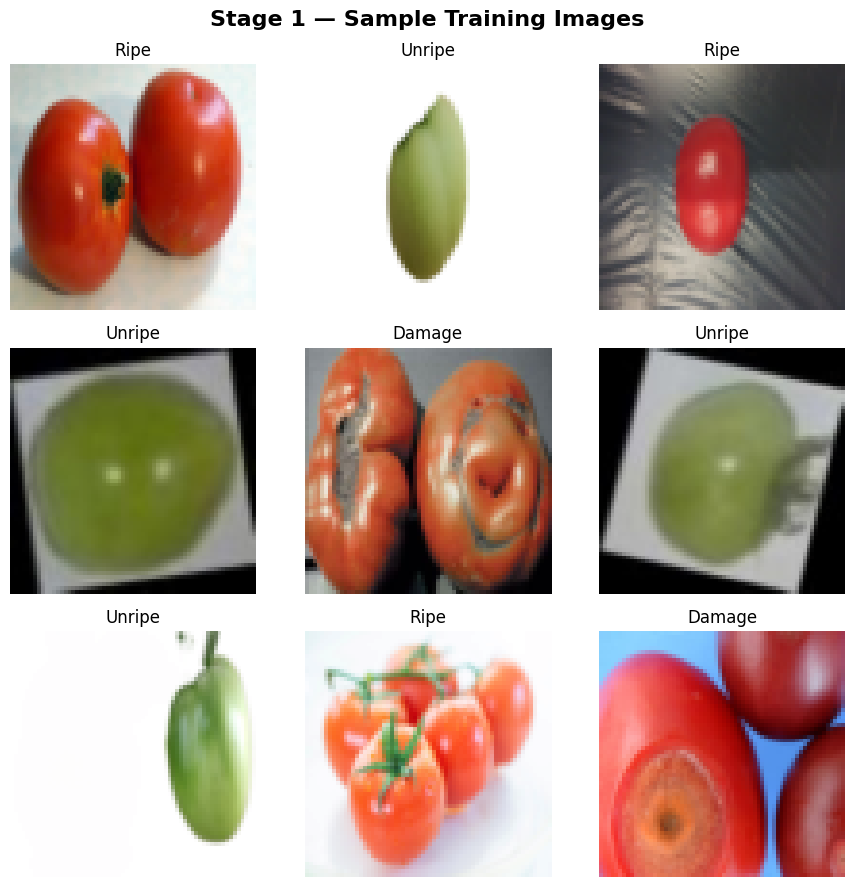

Sample images displayed.


In [8]:
def unnormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """
    Reverses the normalisation applied during transforms so images display correctly.
    Without this, images appear washed out or with wrong colours.
    """
    tensor = tensor.clone()                                # Clone to avoid modifying the original
    for t, m, s in zip(tensor, mean, std):                # Loop over each color channel
        t.mul_(s).add_(m)                                  # Reverse: pixel = (pixel * std) + mean
    return tensor.clamp(0, 1)                              # Clamp values to valid range [0, 1]

# --- Grab one batch of training images to visualise ---
images, labels = next(iter(train_loader_s1))   # Get first batch from the training loader

# --- Create a 3×3 grid of sample images ---
fig, axes = plt.subplots(3, 3, figsize=(9, 9))  # Create a figure with 3 rows and 3 columns
fig.suptitle("Stage 1 — Sample Training Images", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flatten()):        # Loop over each subplot
    img = unnormalize(images[i])               # Undo normalisation for display
    img_np = img.permute(1, 2, 0).numpy()      # Change from (C, H, W) to (H, W, C) for matplotlib
    ax.imshow(img_np)                           # Display the image
    ax.set_title(class_names_s1[labels[i].item()], fontsize=12)  # Show class name as title
    ax.axis('off')                             # Hide axis ticks and labels

plt.tight_layout()   # Adjust spacing between subplots
plt.show()           # Display the figure
print("Sample images displayed.")

## CNN Model (Stage 1: Binary Classifier)
This model learns to tell apart Ripe, Unripe and Damaged tomatoes.

In [9]:
class TomatoCNN(nn.Module):
    """
    A simple CNN built from scratch for tomato image classification.
    Works for both binary (Stage 1) and multi-class (Stage 2) by passing num_classes.
    """

    def __init__(self, num_classes=3, image_size=64):
        """
        Constructor: defines all the layers of the network.
        num_classes : number of output categories (2 for Stage 1, N for Stage 2, N for stage 3)
        image_size  : input image size (must match IMAGE_SIZE hyperparameter)
        """
        super(TomatoCNN, self).__init__()  # Call parent class constructor

        # --- Convolutional Feature Extractor ---
        # Three convolutional blocks, each followed by BatchNorm, ReLU, and MaxPool
        self.features = nn.Sequential(

            # Block 1: learns simple edges and colour patterns
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # Input: 3 channels (RGB), Output: 32 feature maps
            nn.BatchNorm2d(32),                            # Normalise activations for stable training
            nn.ReLU(inplace=True),                         # Non-linearity: replace negatives with 0
            nn.MaxPool2d(kernel_size=2, stride=2),         # Halve spatial size: 64→32

            # Block 2: learns more complex shapes and textures
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Input: 32, Output: 64 feature maps
            nn.BatchNorm2d(64),                            # Batch normalisation
            nn.ReLU(inplace=True),                         # Activation
            nn.MaxPool2d(kernel_size=2, stride=2),         # Halve spatial size: 32→16

            # Block 3: learns high-level features like disease spots or colour gradients
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # Input: 64, Output: 128 feature maps
            nn.BatchNorm2d(128),                           # Batch normalisation
            nn.ReLU(inplace=True),                         # Activation
            nn.MaxPool2d(kernel_size=2, stride=2),         # Halve spatial size: 16→8
        )

        # Calculate the size of the flattened feature vector after the conv blocks
        # After 3× MaxPool2d with stride 2: spatial size = image_size // 8
        flat_features = 128 * (image_size // 8) * (image_size // 8)

        # --- Fully Connected Classifier ---
        # Takes flattened features and maps them to class scores
        self.classifier = nn.Sequential(
            nn.Flatten(),                                  # Convert (128, 8, 8) → flat vector of 8192
            nn.Linear(flat_features, 256),                 # Dense layer: 8192 → 256 neurons
            nn.ReLU(inplace=True),                         # Non-linearity
            nn.Dropout(p=0.5),                             # Randomly zero 50% of neurons to prevent overfitting
            nn.Linear(256, num_classes),                   # Final layer: 256 → num_classes scores
        )

    def forward(self, x):
        """
        Defines how data flows through the network (forward pass).
        x: input image batch of shape (batch_size, 3, H, W)
        """
        x = self.features(x)      # Pass through convolutional blocks
        x = self.classifier(x)    # Pass through fully connected layers
        return x                  # Return raw class scores (logits)


# --- Instantiate the Stage 1 model ---
model_s1 = TomatoCNN(num_classes=num_classes_s1, image_size=IMAGE_SIZE)

# --- Print model summary using a dummy input tensor ---
dummy_input = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)  # Fake batch of 1 image
output = model_s1(dummy_input)                            # Run forward pass
print(f" Stage 1 Model created!")
print(f"   Output shape for 1 image: {output.shape}  (should be [1, {num_classes_s1}])")
print(f"\n{model_s1}")   # Print full model architecture

 Stage 1 Model created!
   Output shape for 1 image: torch.Size([1, 3])  (should be [1, 3])

TomatoCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0)

## Training Setup (Stage 1)
Configure the loss function, optimiser, and learning rate scheduler.

In [10]:
# --- Move model to the selected device (GPU or CPU) ---
model_s1 = model_s1.to(device)  # All computations will happen on the GPU (if available)

# --- Loss function: CrossEntropyLoss ---
# Used for classification; combines log-softmax + negative log-likelihood
criterion = nn.CrossEntropyLoss()

# --- Optimiser: Adam ---
# Adam adapts the learning rate per-parameter; generally faster than plain SGD
optimizer_s1 = optim.Adam(model_s1.parameters(), lr=LEARNING_RATE)

# --- Learning Rate Scheduler: StepLR ---
# Reduces learning rate by factor gamma every step_size epochs
# Here: LR is multiplied by 0.1 every 7 epochs → 0.001 → 0.0001 → ...
scheduler_s1 = optim.lr_scheduler.StepLR(optimizer_s1, step_size=7, gamma=0.1)

print(" Training setup complete.")
print(f"   Loss function : CrossEntropyLoss")
print(f"   Optimiser     : Adam  (lr={LEARNING_RATE})")
print(f"   LR Scheduler  : StepLR (step=7, gamma=0.1)")

 Training setup complete.
   Loss function : CrossEntropyLoss
   Optimiser     : Adam  (lr=0.001)
   LR Scheduler  : StepLR (step=7, gamma=0.1)


## Training Loop (Stage 1)
Train the model for `EPOCHS` passes, tracking loss and accuracy on both train and validation sets. The best model weights are saved automatically.

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, save_path):
    """
    Full training loop with validation.
    Saves the best model weights based on validation accuracy.

    Returns: history dict with train/val loss and accuracy per epoch.
    """
    # --- History containers to track metrics over time ---
    history = {
        'train_loss': [],   # Training loss per epoch
        'train_acc':  [],   # Training accuracy per epoch
        'val_loss':   [],   # Validation loss per epoch
        'val_acc':    [],   # Validation accuracy per epoch
    }

    best_val_acc = 0.0   # Track the best validation accuracy seen so far

    # --- Epoch loop ---
    for epoch in range(epochs):
        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print("-" * 40)

        # ══════════════════════════════════════
        # PHASE 1: TRAINING
        # ══════════════════════════════════════
        model.train()               # Set model to training mode (enables dropout, batchnorm update)
        running_loss = 0.0          # Accumulate loss across all batches
        correct_preds = 0           # Count correct predictions
        total_samples = 0           # Count total samples processed

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)   # Move image batch to GPU/CPU
            labels = labels.to(device)   # Move label batch to GPU/CPU

            optimizer.zero_grad()         # Reset gradients from previous batch
            outputs = model(images)       # Forward pass: get raw class scores
            loss = criterion(outputs, labels)  # Compute loss between predictions and true labels
            loss.backward()               # Backpropagation: compute gradients
            optimizer.step()              # Update model weights using gradients

            running_loss += loss.item() * images.size(0)  # Accumulate weighted loss
            _, predicted = torch.max(outputs, dim=1)       # Get class with highest score
            correct_preds += (predicted == labels).sum().item()  # Count correct
            total_samples += labels.size(0)                       # Count total

        # Compute average training loss and accuracy for this epoch
        epoch_train_loss = running_loss / total_samples
        epoch_train_acc  = correct_preds / total_samples * 100

        # ══════════════════════════════════════
        # PHASE 2: VALIDATION
        # ══════════════════════════════════════
        model.eval()                  # Set model to evaluation mode (disables dropout, freezes batchnorm)
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():         # Disable gradient computation (saves memory during eval)
            for images, labels in val_loader:
                images = images.to(device)          # Move to device
                labels = labels.to(device)
                outputs = model(images)              # Forward pass only (no gradients)
                loss = criterion(outputs, labels)    # Compute validation loss
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, dim=1)  # Predicted class
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc  = val_correct / val_total * 100

        # --- Step the learning rate scheduler at end of each epoch ---
        scheduler.step()

        # --- Print epoch summary ---
        print(f"  Train Loss: {epoch_train_loss:.4f}  |  Train Acc: {epoch_train_acc:.2f}%")
        print(f"  Val   Loss: {epoch_val_loss:.4f}  |  Val   Acc: {epoch_val_acc:.2f}%")
        print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")

        # --- Save the model if it improved on validation accuracy ---
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc                    # Update the best seen so far
            torch.save(model.state_dict(), save_path)       # Save model weights to disk
            print(f"  New best model saved! Val Acc: {best_val_acc:.2f}%")

        # --- Append metrics to history for later plotting ---
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

    print(f"\n Training complete. Best Val Accuracy: {best_val_acc:.2f}%")
    return history


# --- Run training for Stage 1 ---
SAVE_PATH_S1 = '/content/best_model_stage1.pth'   # Path where best weights will be saved

print(" Starting Stage 1 Training...")
history_s1 = train_model(
    model=model_s1,
    train_loader=train_loader_s1,
    val_loader=val_loader_s1,
    criterion=criterion,
    optimizer=optimizer_s1,
    scheduler=scheduler_s1,
    epochs=EPOCHS,
    save_path=SAVE_PATH_S1
)

 Starting Stage 1 Training...

Epoch [1/15]
----------------------------------------
  Train Loss: 0.8052  |  Train Acc: 84.23%
  Val   Loss: 0.1662  |  Val   Acc: 93.80%
  LR: 0.001000
  New best model saved! Val Acc: 93.80%

Epoch [2/15]
----------------------------------------
  Train Loss: 0.1513  |  Train Acc: 94.33%
  Val   Loss: 0.0985  |  Val   Acc: 95.87%
  LR: 0.001000
  New best model saved! Val Acc: 95.87%

Epoch [3/15]
----------------------------------------
  Train Loss: 0.1317  |  Train Acc: 95.84%
  Val   Loss: 0.0949  |  Val   Acc: 95.87%
  LR: 0.001000

Epoch [4/15]
----------------------------------------
  Train Loss: 0.1067  |  Train Acc: 96.19%
  Val   Loss: 0.0865  |  Val   Acc: 97.93%
  LR: 0.001000
  New best model saved! Val Acc: 97.93%

Epoch [5/15]
----------------------------------------
  Train Loss: 0.1081  |  Train Acc: 96.46%
  Val   Loss: 0.0436  |  Val   Acc: 97.52%
  LR: 0.001000

Epoch [6/15]
----------------------------------------
  Train Loss: 0

## Plot Training Curves (Stage 1)
Visualise how training and validation loss/accuracy changed over each epoch.

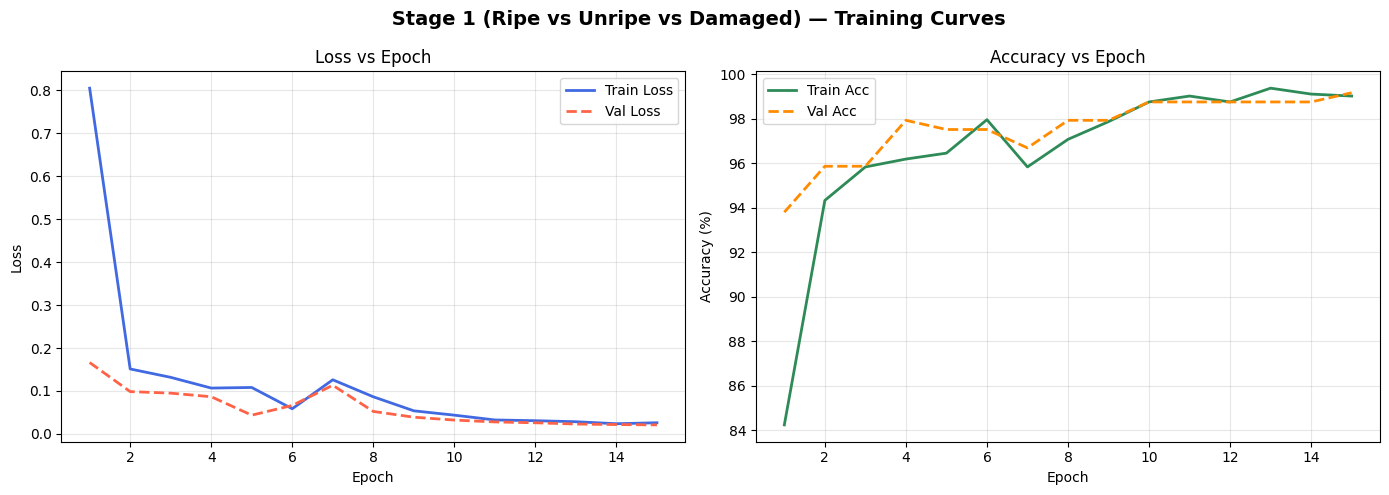

In [12]:
def plot_training_curves(history, title_prefix="Stage 1"):
    """
    Plot training and validation Loss and Accuracy side by side.
    history      : dict with keys 'train_loss', 'val_loss', 'train_acc', 'val_acc'
    title_prefix : label shown in plot title
    """
    epochs_range = range(1, len(history['train_loss']) + 1)  # x-axis: epoch numbers

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # Create two side-by-side plots
    fig.suptitle(f" {title_prefix} — Training Curves", fontsize=14, fontweight='bold')

    # --- Left plot: Loss ---
    ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
    ax1.set_title('Loss vs Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Right plot: Accuracy ---
    ax2.plot(epochs_range, history['train_acc'], label='Train Acc', color='seagreen',  linewidth=2)
    ax2.plot(epochs_range, history['val_acc'],   label='Val Acc',   color='darkorange', linewidth=2, linestyle='--')
    ax2.set_title('Accuracy vs Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()   # Adjust spacing
    plt.show()           # Display the plots


plot_training_curves(history_s1, title_prefix="Stage 1 (Ripe vs Unripe vs Damaged)")

## Evaluate Stage 1 on Test Set
Load the best saved model and run inference on the unseen test set. Print accuracy, classification report, and confusion matrix.


 Stage 1 (Ripe vs Unripe vs Damaged) — Test Accuracy: 97.12%

 Classification Report:
              precision    recall  f1-score   support

      Damage       0.84      0.97      0.90        33
        Ripe       1.00      0.91      0.95        66
      Unripe       0.99      1.00      1.00       144

    accuracy                           0.97       243
   macro avg       0.95      0.96      0.95       243
weighted avg       0.97      0.97      0.97       243



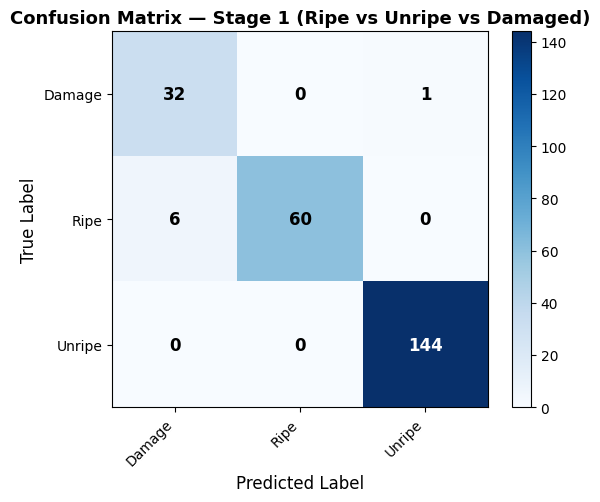

In [13]:
def evaluate_model(model, test_loader, class_names, save_path, stage_label="Stage 1"):
    """
    Load the best saved weights, run inference on the test set,
    and print accuracy + full classification report + confusion matrix.
    """
    # --- Load the best model weights saved during training ---
    model.load_state_dict(torch.load(save_path, map_location=device))  # Load weights
    model.eval()    # Set to evaluation mode

    all_preds  = []   # Store all predictions
    all_labels = []   # Store all true labels

    # --- Run inference on all test batches ---
    with torch.no_grad():   # No gradients needed during evaluation
        for images, labels in test_loader:
            images = images.to(device)          # Move batch to device
            outputs = model(images)              # Forward pass
            _, predicted = torch.max(outputs, 1) # Get predicted class indices
            all_preds.extend(predicted.cpu().numpy())   # Collect predictions
            all_labels.extend(labels.cpu().numpy())     # Collect true labels

    # Convert lists to numpy arrays for sklearn metrics
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # --- Overall accuracy ---
    overall_acc = (all_preds == all_labels).mean() * 100
    print(f"\n {stage_label} — Test Accuracy: {overall_acc:.2f}%")

    # --- Detailed classification report ---
    print(f"\n Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # --- Confusion matrix ---
    cm = confusion_matrix(all_labels, all_preds)   # Compute matrix
    fig, ax = plt.subplots(figsize=(max(6, len(class_names)), max(5, len(class_names)-1)))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')   # Heatmap
    plt.colorbar(im, ax=ax)                                      # Add colour bar
    ax.set_xticks(range(len(class_names)))                       # x-axis: predicted labels
    ax.set_yticks(range(len(class_names)))                       # y-axis: true labels
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'Confusion Matrix — {stage_label}', fontsize=13, fontweight='bold')

    # Annotate each cell in the matrix with its count
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return overall_acc   # Return accuracy for use in the summary cell


# --- Evaluate Stage 1 ---
acc_s1 = evaluate_model(
    model=model_s1,
    test_loader=test_loader_s1,
    class_names=class_names_s1,
    save_path=SAVE_PATH_S1,
    stage_label="Stage 1 (Ripe vs Unripe vs Damaged)"
)

## Predict on a Single New Image
Use either trained model to classify any new tomato image from your Google Drive or local path.

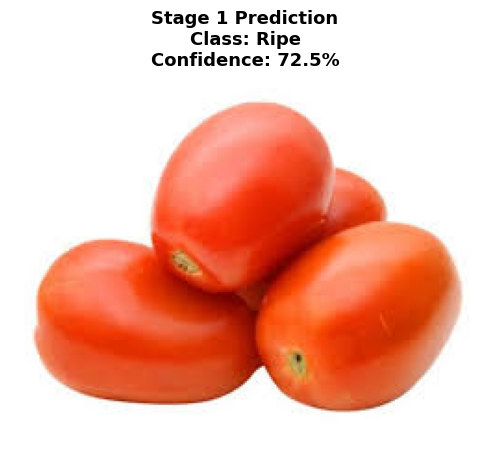


🔍 Prediction: Ripe  (72.5% confident)
('Ripe', 72.46737480163574)


In [14]:
from PIL import Image   # Python Imaging Library to open image files

def predict_image(image_path, model, class_names, stage="Stage 1"):
    """
    Loads a single image, runs it through the model, and displays the prediction.

    image_path  : full path to the image file (str)
    model       : the trained PyTorch model (model_s1 or model_s2)
    class_names : list of class label strings for the chosen stage
    stage       : label string used in the plot title
    """
    # --- Load image from disk ---
    img = Image.open(image_path).convert('RGB')  # Open image and ensure it's in RGB format

    # --- Apply the same preprocessing used during training ---
    img_tensor = val_test_transforms(img)         # Returns a tensor of shape (3, H, W)
    img_tensor = img_tensor.unsqueeze(0)           # Add batch dimension: (1, 3, H, W)
    img_tensor = img_tensor.to(device)             # Move to the same device as the model

    # --- Run inference ---
    model.eval()                                   # Set to evaluation mode
    with torch.no_grad():                          # No gradients needed
        outputs = model(img_tensor)                # Forward pass → raw scores (logits)
        probabilities = torch.softmax(outputs, dim=1)  # Convert logits to probabilities
        confidence, predicted_idx = torch.max(probabilities, dim=1)  # Top prediction

    # Extract predicted class name and confidence percentage
    predicted_class = class_names[predicted_idx.item()]   # Map index to class name
    confidence_pct  = confidence.item() * 100              # Convert to percentage

    # --- Display the image with prediction as title ---
    plt.figure(figsize=(5, 5))
    plt.imshow(img)                                         # Show original image (before normalisation)
    plt.title(
        f"{stage} Prediction\n"
        f"Class: {predicted_class}\n"
        f"Confidence: {confidence_pct:.1f}%",
        fontsize=13, fontweight='bold'
    )
    plt.axis('off')   # Hide axes
    plt.tight_layout()
    plt.show()

    print(f"\n🔍 Prediction: {predicted_class}  ({confidence_pct:.1f}% confident)")
    return predicted_class, confidence_pct


# ─────────────────────────────────────────────────
#  HOW TO USE THIS FUNCTION:
# ─────────────────────────────────────────────────
# For Stage 1 (Ripe vs Unripe vs Damaged):
#   predict_image('/path/to/tomato.jpg', model_s1, class_names_s1, stage='Stage 1')


# --- EXAMPLE: Replace this path with a real image path from your Drive ---
EXAMPLE_IMAGE_PATH = '/content/drive/MyDrive/images.jpg'
output = predict_image(EXAMPLE_IMAGE_PATH, model_s1, class_names_s1)
print(output)
# print(" predict_image() function is ready.")
# print("   Uncomment the last two lines above and provide a valid image path to test it.")

In [15]:
# Recommendation to farmer
if class_names_s1 == 'ripe':
  print('Healthy and ready for consumption')
elif class_names_s1 == 'unripe':
  print('Store')
else:
  print('Return to farmer')

Return to farmer


## Summary
Final results

In [16]:
# Print the final pipeline summary
print("=" * 50)
print(" Pipeline Summary")
print("=" * 50)
print(f"  Stage 1: Ripe/Unripe/Damaged Classifier  → {acc_s1:.2f}%")
print("=" * 50)


 Pipeline Summary
  Stage 1: Ripe/Unripe/Damaged Classifier  → 97.12%


## Load Saved Model for Inference

This cell demonstrates how to load the previously saved model weights (`best_model_stage1.pth`) into a new instance of the `TomatoCNN` model for performing inferences.

In [ ]:
# Instantiate a new model (it's important to use the same architecture as during training)
loaded_model_s1 = TomatoCNN(num_classes=num_classes_s1, image_size=IMAGE_SIZE)

# Load the saved state dictionary into the new model instance
loaded_model_s1.load_state_dict(torch.load(SAVE_PATH_S1, map_location=device))

# Set the model to evaluation mode
loaded_model_s1.eval()

print(f"Model loaded successfully from {SAVE_PATH_S1}")

Model loaded successfully from /content/best_model_stage1.pth


## Streamlit Application Deployment Steps

To run this Streamlit application, follow these steps:

### 1. Save the Python script

Copy the entire Python script below and save it as a Python file (e.g., `tomato_classifier_app.py`) on your local machine. This script contains the model definition, image transformations, prediction logic, and the Streamlit UI code.

In [ ]:
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import os

# --- Configuration and Hyperparameters (Match your Colab notebook settings) ---
IMAGE_SIZE = 64
num_classes_s1 = 3  # For 'Damaged', 'ripe', 'unripe'
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names for Stage 1
class_names_s1 = ['Damaged', 'ripe', 'unripe']

# --- Model Definition (TomatoCNN - must be identical to training) ---
class TomatoCNN(nn.Module):
    def __init__(self, num_classes=3, image_size=64):
        super(TomatoCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        flat_features = 128 * (image_size // 8) * (image_size // 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# --- Image Transformations for Inference ---
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# --- Prediction Function ---
def predict_image(image_file, model, class_names):
    img = Image.open(image_file).convert('RGB')
    img_tensor = val_test_transforms(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, dim=1)

    predicted_class = class_names[predicted_idx.item()]
    confidence_pct = confidence.item() * 100

    return predicted_class, confidence_pct, img

# --- Streamlit Application UI ---
st.set_page_config(layout="centered", page_title="Tomato Classifier", icon="🍅")

# Sidebar content
st.sidebar.header("About This App")
st.sidebar.write(
    "This application uses a Convolutional Neural Network (CNN) to classify tomato images."
    "It can identify if a tomato is **ripe**, **unripe**, or **damaged**."
)
st.sidebar.image("Tomato Gif.gif", use_column_width=False")
st.sidebar.markdown("--- ")
st.sidebar.header("How to Use")
st.sidebar.info(
    "1. Upload an image of a tomato using the file uploader."
    "2. The model will then predict its condition."
    "3. Get instant recommendations!"
)

st.title("🍅 Tomato Quality Classifier")
st.markdown("Upload an image of a tomato to classify its state.")

# Load the model
@st.cache_resource
def load_model():
    model = TomatoCNN(num_classes=num_classes_s1, image_size=IMAGE_SIZE)
    # IMPORTANT: Ensure 'best_model_stage1.pth' is in the same directory as this script
    model_path = "best_model_stage1.pth"
    if not os.path.exists(model_path):
        st.error(f"Model weights file '{model_path}' not found. Please ensure it's in the same directory as this Streamlit app.")
        st.stop()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

model_s1 = load_model()

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    st.image(uploaded_file, caption="Uploaded Image", use_column_width=True)
    st.write("")
    st.write("Classifying...")

    # Display a spinner while classifying
    with st.spinner('Analyzing the tomato...'):
        predicted_class, confidence_pct, original_img = predict_image(uploaded_file, model_s1, class_names_s1)

    st.success(f"Prediction: **{predicted_class}** with **{confidence_pct:.2f}%** confidence")

    # Display recommendations based on prediction
    st.subheader("Recommendation:")
    if predicted_class == 'ripe':
        st.write("This tomato is **ripe**! It's healthy and ready for consumption. Enjoy!")
        st.balloons() # Add a small celebration
    elif predicted_class == 'unripe':
        st.write("This tomato is **unripe**. You can store it to ripen further at room temperature.")
    elif predicted_class == 'Damaged':
        st.write("This tomato appears **damaged**. It may not be suitable for consumption and could be returned or discarded. Consider composting!")
    else:
        st.write("No specific recommendation for this class.")

st.markdown("--- ")
st.markdown("Developed by GROUP 1")


ModuleNotFoundError: No module named 'streamlit'

In [ ]:
!pip install streamlit -q

In [ ]:
!pip install streamlit -q

### 2. Install Streamlit

If you don't have Streamlit installed on your local machine, open your terminal or command prompt and run:

```bash
pip install streamlit
```

### 3. Download Model Weights

The Streamlit app expects the trained model weights file named `best_model_stage1.pth` to be in the **same directory** as your `tomato_classifier_app.py` file.

You can download this file from your Colab environment. In the Colab file browser (the folder icon on the left sidebar), navigate to `/content/`, find `best_model_stage1.pth`, right-click it, and select 'Download'.

### 4. Run the Streamlit app

Open your terminal or command prompt, navigate to the directory where you saved the `tomato_classifier_app.py` file and the `best_model_stage1.pth` model weights, and run:

```bash
streamlit run tomato_classifier_app.py
```

This will open the application in your web browser.